<div style = "text-align: center;">
    <h1>FAKE REVIEWS DETECTION</h1>
</div>

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import seaborn as sns
import plotly.express as px
from collections import Counter

## Import and preprocessing

In [5]:
df = pd.read_csv('fake-reviews-dataset.csv')

df.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


In [6]:
print(df.isnull().sum())


category    0
rating      0
label       0
text_       0
dtype: int64


In [7]:
df.duplicated().sum()


np.int64(12)

In [8]:
df['label'].value_counts()

label
CG    20216
OR    20216
Name: count, dtype: int64

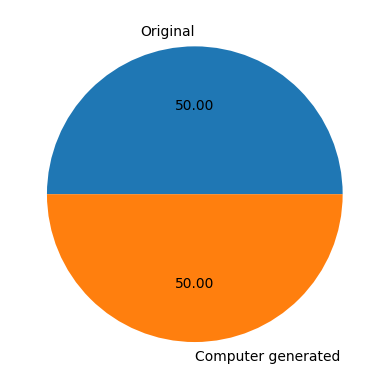

In [9]:
plt.pie(df['label'].value_counts(), labels=['Original', 'Computer generated'],autopct="%0.2f")
plt.show()

In [10]:
df['num_characters'] = df['text_'].apply(len)
df['num_words'] = df['text_'].apply(lambda x:len(nltk.word_tokenize(x)))
df['num_sentences'] = df['text_'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [11]:
df.head()

,category,rating,label,text_,num_characters,num_words,num_sentences
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor...",75,18,3
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I...",80,19,2
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...,67,16,2
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i...",81,19,2
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...,85,20,3


In [12]:
df.describe()

,rating,num_characters,num_words,num_sentences
count,40432.000000,40432.000000,40432.000000,40432.000000
mean,4.256579,352.058221,76.671003,5.276143
std,1.144354,371.071753,79.230384,4.914112
min,1.000000,24.000000,2.000000,1.000000
25%,4.000000,107.000000,24.000000,2.000000
50%,5.000000,198.000000,44.000000,3.000000
75%,5.000000,440.000000,96.000000,6.000000
max,5.000000,2836.000000,510.000000,133.000000


In [13]:
print(df['label'].value_counts())


label
CG    20216
OR    20216
Name: count, dtype: int64


### Visual description

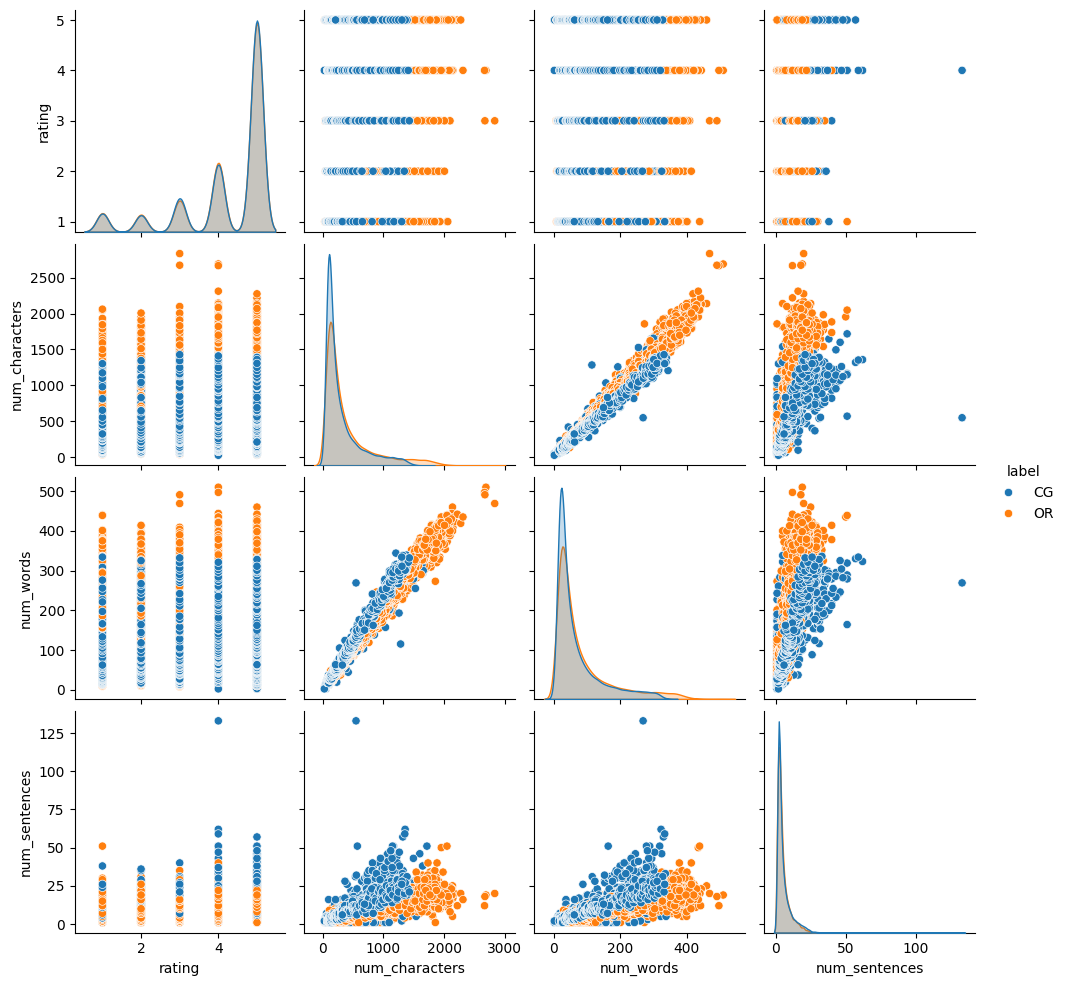

In [14]:
import seaborn as sns

sns.pairplot(df,hue='label')

* HeatMap for numarical data

<Axes: >

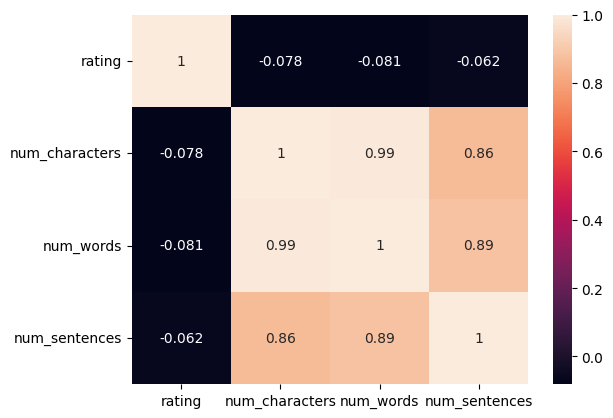

In [15]:
#se due colonne hanno correlazione elevata tra di loro,
#tendono a muovesi insieme linearmente
df_numeric = df.select_dtypes(include = 'number')
sns.heatmap(df_numeric.corr(),annot=True)

### Stopwords remove and word tokenize

In [16]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize


In [17]:
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ludov\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ludov\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [18]:
nltk.download('punkt_tab')

# Imposta il percorso di ricerca dei dati NLTK
nltk.data.path.append('E:/nltk_data')  # Modifica con il percorso corretto, se diverso

# Prova a tokenizzare di nuovo
test_sentence = "Questo è un test di tokenizzazione."
tokens = nltk.word_tokenize(test_sentence)
print(tokens)


['Questo', 'è', 'un', 'test', 'di', 'tokenizzazione', '.']


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ludov\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [19]:
stop_words = set(stopwords.words('english'))

In [20]:

def preprocess_text(text):
    tokens = word_tokenize(text.lower())  # Tokenizza e trasforma tutto in minuscolo
    tokens = [word for word in tokens if word.isalpha()]  # Rimuove numeri e caratteri speciali
    tokens = [word for word in tokens if word not in stop_words]  # Rimuove stopwords
    return ' '.join(tokens)



In [21]:

df['cleaned_text'] = df['text_'].apply(preprocess_text)



In [22]:
# Visualizza i risultati
df.head()

,category,rating,label,text_,num_characters,num_words,num_sentences,cleaned_text
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor...",75,18,3,love well made sturdy comfortable love pretty
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I...",80,19,2,love great upgrade original mine couple years
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...,67,16,2,pillow saved back love look feel pillow
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i...",81,19,2,missing information use great product price
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...,85,20,3,nice set good quality set two months


### Stemming

*Lemmatizzazione (stemming) = le parole vengono semplificate. Ad esempio running diventa run*

In [23]:
from nltk.stem import PorterStemmer

nltk.download('punkt')  # Solo la prima volta per scaricare il tokenizer

# Inizializza lo stemmer
stemmer = PorterStemmer()

# Esempio di testo da stemmare
text = "running runner ran easily the boys are playing games"

# Tokenizza il testo
words = word_tokenize(text)

# Applica lo stemming su ogni parola
stemmed_words = [stemmer.stem(word) for word in words]

# Stampa le parole stemmate
print("Parole originali:", words)
print("Parole stemmate:", stemmed_words)


Parole originali: ['running', 'runner', 'ran', 'easily', 'the', 'boys', 'are', 'playing', 'games']
Parole stemmate: ['run', 'runner', 'ran', 'easili', 'the', 'boy', 'are', 'play', 'game']


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ludov\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [24]:
# Funzione per applicare lo stemming
def apply_stemming(text):
    # Tokenizza il testo
    words = word_tokenize(text)
    # Applica lo stemming su ogni parola
    stemmed_words = [stemmer.stem(word) for word in words]
    # Ritorna il testo stemmato come stringa
    return ' '.join(stemmed_words)

# Applica la funzione di stemming alla colonna 'cleaned_text'
df['stemmed_text'] = df['cleaned_text'].apply(apply_stemming)

# Stampa il DataFrame con la nuova colonna stemmata
display(df.head(6))

,category,rating,label,text_,num_characters,num_words,num_sentences,cleaned_text,stemmed_text
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor...",75,18,3,love well made sturdy comfortable love pretty,love well made sturdi comfort love pretti
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I...",80,19,2,love great upgrade original mine couple years,love great upgrad origin mine coupl year
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...,67,16,2,pillow saved back love look feel pillow,pillow save back love look feel pillow
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i...",81,19,2,missing information use great product price,miss inform use great product price
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...,85,20,3,nice set good quality set two months,nice set good qualiti set two month
5,Home_and_Kitchen_5,3.0,CG,I WANTED DIFFERENT FLAVORS BUT THEY ARE NOT.,44,9,1,wanted different flavors,want differ flavor


In [25]:
#stampo solo le colonne desiderate
df_filtered = df[['text_','cleaned_text','stemmed_text']]
pd.set_option('display.max_colwidth', None)
display(df_filtered.head(5))

,text_,cleaned_text,stemmed_text
0,"Love this! Well made, sturdy, and very comfortable. I love it!Very pretty",love well made sturdy comfortable love pretty,love well made sturdi comfort love pretti
1,"love it, a great upgrade from the original. I've had mine for a couple of years",love great upgrade original mine couple years,love great upgrad origin mine coupl year
2,This pillow saved my back. I love the look and feel of this pillow.,pillow saved back love look feel pillow,pillow save back love look feel pillow
3,"Missing information on how to use it, but it is a great product for the price! I",missing information use great product price,miss inform use great product price
4,Very nice set. Good quality. We have had the set for two months now and have not been,nice set good quality set two months,nice set good qualiti set two month


In [26]:
#esempio
display(df.iloc[20000])

category                                                                                   Pet_Supplies_5
rating                                                                                                5.0
label                                                                                                  OR
text_             Exactly as advertised. It is sturdy, easy to assemble, and just right my 8 pound puppy.
num_characters                                                                                         87
num_words                                                                                              20
num_sentences                                                                                           2
cleaned_text                                    exactly advertised sturdy easy assemble right pound puppy
stemmed_text                                       exactli advertis sturdi easi assembl right pound puppi
Name: 20000, dtype: object

## Bag of words

Trasformazione del testo in feature
Uso il Bag of Words (BoW) che conta la frequenza delle parole
e il TF-IDF (Team Frequency-Inverse Document Frequency) che misura l'importanza delle parole rispetto al corpus


In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

df = df.dropna(subset=['stemmed_text'])
df['stemmed_text'] = df['stemmed_text'].fillna('')

print(df['stemmed_text'].isnull().sum())


0


In [28]:
vectorizer = TfidfVectorizer(max_features=5000)     #massimo 5000 parole piu importanti
X = vectorizer.fit_transform(df['stemmed_text'])    #trasforma i testi in vettori TF-IDF

## New Feature: Sentiment

In [29]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score


# Preprocessing
stop_words = set(stopwords.words('english'))
def preprocess_text(text):
    tokens = nltk.word_tokenize(text.lower())
    tokens = [word for word in tokens if word.isalnum() and word not in stop_words]
    return ' '.join(tokens)

df['processed_text'] = df['text_'].apply(preprocess_text)



In [58]:
#Bag of words of representation
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['processed_text'])
y = (df['label'] == 'OR').astype(int)   #converti le etichette in binari 0 o 1

#split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#train sentiment analysis model (naive bayes classifier)
#clf = MultinomialNB()
#clf.fit(X_train, y_train)


In [31]:
from textblob import TextBlob
#assegno a ciascuna recensione il sentiment effettivo
def get_true_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    elif rating >= 4:
        return "Positive"
    
# Funzione per determinare il sentiment label basato sulla polarità
def get_sentiment_label(polarity):
    if polarity > 0:
        return "Positive"
    if polarity < 0:
        return "Negative"
    else:
        return "Neutral"
    
df['true_sentiment'] = df['rating'].apply(get_true_sentiment)

# Aggiunge la colonna 'sentiment' solo se non esiste già
if 'sentiment' not in df.columns:
    sentiments = []
    for text in df['text_']:
        # Calcola il sentiment usando TextBlob
        sentiment = TextBlob(text).sentiment
        polarity = sentiment.polarity
        # Determina il label usando la polarità
        sentiment_label = get_sentiment_label(polarity)
        sentiments.append(sentiment_label)

 # Aggiunge la lista dei sentimenti calcolati al DataFrame
    df['sentiment'] = sentiments

In [32]:
pd.reset_option('display.max_colwidth')     #rimetto che non mostra tutto il testo
display(df)

,category,rating,label,text_,num_characters,num_words,num_sentences,cleaned_text,stemmed_text,processed_text,true_sentiment,sentiment
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor...",75,18,3,love well made sturdy comfortable love pretty,love well made sturdi comfort love pretti,love well made sturdy comfortable love pretty,Positive,Positive
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I...",80,19,2,love great upgrade original mine couple years,love great upgrad origin mine coupl year,love great upgrade original mine couple years,Positive,Positive
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...,67,16,2,pillow saved back love look feel pillow,pillow save back love look feel pillow,pillow saved back love look feel pillow,Positive,Positive
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i...",81,19,2,missing information use great product price,miss inform use great product price,missing information use great product price,Negative,Positive
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...,85,20,3,nice set good quality set two months,nice set good qualiti set two month,nice set good quality set two months,Positive,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...
40427,Clothing_Shoes_and_Jewelry_5,4.0,OR,I had read some reviews saying that this bra r...,1698,379,22,read reviews saying bra ran small ordered two ...,read review say bra ran small order two band c...,read reviews saying bra ran small ordered two ...,Positive,Positive
40428,Clothing_Shoes_and_Jewelry_5,5.0,CG,I wasn't sure exactly what it would be. It is ...,1305,311,28,sure exactly would little large small size thi...,sure exactli would littl larg small size think...,sure exactly would little large small size thi...,Positive,Positive
40429,Clothing_Shoes_and_Jewelry_5,2.0,OR,"You can wear the hood by itself, wear it with ...",2007,414,26,wear hood wear hood wear jacket without hood s...,wear hood wear hood wear jacket without hood s...,wear hood wear hood wear jacket without hood s...,Negative,Positive
40430,Clothing_Shoes_and_Jewelry_5,1.0,CG,I liked nothing about this dress. The only rea...,1301,334,26,liked nothing dress reason gave stars ordered ...,like noth dress reason gave star order size fi...,liked nothing dress reason gave 4 stars ordere...,Negative,Positive


In [33]:
fake_reviews = df[df['label']=='CG']
genuine_reviews = df[df['label']=='OR']

num_fake_reviews_positive = (fake_reviews['sentiment'] == "Positive").sum()
num_fake_reviews_negative = (fake_reviews['sentiment'] == "Negative").sum()

num_genuine_reviews_positive = (genuine_reviews['sentiment'] == "Positive").sum()
num_genuine_reviews_negative = (genuine_reviews['sentiment'] == "Negative").sum()

num_fake_reviews_neutral = (fake_reviews['sentiment'] == "Neutral").sum()
num_genuine_reviews_neutral = (genuine_reviews['sentiment'] == "Neutral").sum()

print("Number of fake reviews predicted as positive (true negative):", num_fake_reviews_positive)
print("Number of fake reviews predicted as negative (false positive):", num_fake_reviews_negative)
print("Number of genuine reviews predicted as positive (true positive):", num_genuine_reviews_positive)
print("Number of genuine reviews predicted as negative (false negative):", num_genuine_reviews_negative)
print("Number of fake reviews predicted as neutral:", num_fake_reviews_neutral)
print("Number of genuine reviews predicted as neutral:", num_genuine_reviews_neutral)


Number of fake reviews predicted as positive (true negative): 17521
Number of fake reviews predicted as negative (false positive): 1902
Number of genuine reviews predicted as positive (true positive): 17665
Number of genuine reviews predicted as negative (false negative): 1981
Number of fake reviews predicted as neutral: 793
Number of genuine reviews predicted as neutral: 570


In [34]:
print(df.columns)

Index(['category', 'rating', 'label', 'text_', 'num_characters', 'num_words',
       'num_sentences', 'cleaned_text', 'stemmed_text', 'processed_text',
       'true_sentiment', 'sentiment'],
      dtype='object')


In [35]:
df['match'] = (df['true_sentiment'] == df['sentiment']).astype(int)

In [36]:
#visualizzo solo quelle con sentiment Negative:
negative_reviews = df[df['sentiment'] == 'Negative']

display(negative_reviews)

,category,rating,label,text_,num_characters,num_words,num_sentences,cleaned_text,stemmed_text,processed_text,true_sentiment,sentiment,match
10,Home_and_Kitchen_5,5.0,CG,As advertised. 5th one I've had. The only prob...,75,19,3,advertised one problem really,advertis one problem realli,advertised 5th one problem really,Positive,Negative,0
35,Home_and_Kitchen_5,3.0,CG,Way too heavy for everyday use. The only reaso...,87,20,2,way heavy everyday use reason gave stars one,way heavi everyday use reason gave star one,way heavy everyday use reason gave 4 stars one,Neutral,Negative,0
39,Home_and_Kitchen_5,1.0,CG,"Awful experience, everything stuck, cooked eve...",93,19,2,awful experience everything stuck cooked evenl...,aw experi everyth stuck cook evenli problem re...,awful experience everything stuck cooked evenl...,Negative,Negative,1
45,Home_and_Kitchen_5,3.0,CG,"Alright for the price,but was a little disappo...",84,17,1,alright price little disappointed quality product,alright price littl disappoint qualiti product,alright price little disappointed quality product,Neutral,Negative,0
47,Home_and_Kitchen_5,1.0,CG,I put paper in one corner of the cabinet and p...,86,20,1,put paper one corner cabinet put piece paper c...,put paper one corner cabinet put piec paper co...,put paper one corner cabinet put piece paper c...,Negative,Negative,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
40225,Clothing_Shoes_and_Jewelry_5,1.0,OR,I can only blame myself for not looking throug...,1347,283,16,blame looking negative reviews bra everything ...,blame look neg review bra everyth peopl said t...,blame looking negative reviews bra everything ...,Negative,Negative,1
40227,Clothing_Shoes_and_Jewelry_5,4.0,OR,"I'm the type of person who, when I find a bran...",1296,284,19,type person find brand style like stick proble...,type person find brand style like stick proble...,type person find brand style like stick proble...,Positive,Negative,0
40235,Clothing_Shoes_and_Jewelry_5,2.0,OR,"Functional, yes. Durable? We didn't get off to...",1368,287,16,functional yes durable get great start togethe...,function ye durabl get great start togeth pesc...,functional yes durable get great start togethe...,Negative,Negative,1
40249,Clothing_Shoes_and_Jewelry_5,5.0,OR,I gave this Peet dryer 5 stars because it perf...,1279,277,18,gave peet dryer stars performs exactly way exp...,gave peet dryer star perform exactli way expec...,gave peet dryer 5 stars performs exactly way e...,Positive,Negative,0


In [37]:
print(df.columns)

Index(['category', 'rating', 'label', 'text_', 'num_characters', 'num_words',
       'num_sentences', 'cleaned_text', 'stemmed_text', 'processed_text',
       'true_sentiment', 'sentiment', 'match'],
      dtype='object')


In [38]:
#ora stampo solo quelle con sentiment positivo
positive_reviews = df[df['sentiment'] == 'Positive']

display(positive_reviews)

,category,rating,label,text_,num_characters,num_words,num_sentences,cleaned_text,stemmed_text,processed_text,true_sentiment,sentiment,match
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor...",75,18,3,love well made sturdy comfortable love pretty,love well made sturdi comfort love pretti,love well made sturdy comfortable love pretty,Positive,Positive,1
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I...",80,19,2,love great upgrade original mine couple years,love great upgrad origin mine coupl year,love great upgrade original mine couple years,Positive,Positive,1
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...,67,16,2,pillow saved back love look feel pillow,pillow save back love look feel pillow,pillow saved back love look feel pillow,Positive,Positive,1
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i...",81,19,2,missing information use great product price,miss inform use great product price,missing information use great product price,Negative,Positive,0
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...,85,20,3,nice set good quality set two months,nice set good qualiti set two month,nice set good quality set two months,Positive,Positive,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
40427,Clothing_Shoes_and_Jewelry_5,4.0,OR,I had read some reviews saying that this bra r...,1698,379,22,read reviews saying bra ran small ordered two ...,read review say bra ran small order two band c...,read reviews saying bra ran small ordered two ...,Positive,Positive,1
40428,Clothing_Shoes_and_Jewelry_5,5.0,CG,I wasn't sure exactly what it would be. It is ...,1305,311,28,sure exactly would little large small size thi...,sure exactli would littl larg small size think...,sure exactly would little large small size thi...,Positive,Positive,1
40429,Clothing_Shoes_and_Jewelry_5,2.0,OR,"You can wear the hood by itself, wear it with ...",2007,414,26,wear hood wear hood wear jacket without hood s...,wear hood wear hood wear jacket without hood s...,wear hood wear hood wear jacket without hood s...,Negative,Positive,0
40430,Clothing_Shoes_and_Jewelry_5,1.0,CG,I liked nothing about this dress. The only rea...,1301,334,26,liked nothing dress reason gave stars ordered ...,like noth dress reason gave star order size fi...,liked nothing dress reason gave 4 stars ordere...,Negative,Positive,0


In [39]:
#neutrali
neutral_reviews = df[df['sentiment'] == 'Neutral']

display(neutral_reviews)

,category,rating,label,text_,num_characters,num_words,num_sentences,cleaned_text,stemmed_text,processed_text,true_sentiment,sentiment,match
5,Home_and_Kitchen_5,3.0,CG,I WANTED DIFFERENT FLAVORS BUT THEY ARE NOT.,44,9,1,wanted different flavors,want differ flavor,wanted different flavors,Neutral,Neutral,1
13,Home_and_Kitchen_5,1.0,CG,These are so flimsy! They are not the quality ...,89,19,2,flimsy quality would expect piece furniture,flimsi qualiti would expect piec furnitur,flimsy quality would expect piece furniture,Negative,Neutral,0
26,Home_and_Kitchen_5,2.0,CG,Not what I am accustomed to. The only reason I...,84,20,2,accustomed reason gave stars,accustom reason gave star,accustomed reason gave 4 stars,Negative,Neutral,0
70,Home_and_Kitchen_5,5.0,OR,i bought this for a friend and he loves it.,43,11,1,bought friend loves,bought friend love,bought friend loves,Positive,Neutral,0
78,Home_and_Kitchen_5,4.0,OR,Just what I wanted to hang my pants and skirts.,47,11,1,wanted hang pants skirts,want hang pant skirt,wanted hang pants skirts,Positive,Neutral,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
38574,Clothing_Shoes_and_Jewelry_5,5.0,OR,Tuve la oportunidad de adquirir dos tiaras de ...,214,40,3,tuve la oportunidad de adquirir dos tiaras de ...,tuve la oportunidad de adquirir do tiara de es...,tuve la oportunidad de adquirir dos tiaras de ...,Positive,Neutral,0
38772,Clothing_Shoes_and_Jewelry_5,3.0,CG,I like the material and the stretchy design. I...,145,37,4,like material stretchy design keep bag collect...,like materi stretchi design keep bag collect b...,like material stretchy design keep bag collect...,Neutral,Neutral,1
38833,Clothing_Shoes_and_Jewelry_5,2.0,CG,"Like I posted on Amazon, I received the same p...",166,37,2,like posted amazon received product two differ...,like post amazon receiv product two differ col...,like posted amazon received product two differ...,Negative,Neutral,0
38891,Clothing_Shoes_and_Jewelry_5,3.0,OR,So i bought this bag for my daughter 6th birth...,260,57,1,bought bag daughter birthday bag beautiful str...,bought bag daughter birthday bag beauti strap ...,bought bag daughter 6th birthday bag beautiful...,Neutral,Neutral,1


In [40]:
#come è andata la classificazione del sentiment??
def get_true_sentiment(rating):
    if rating<=2:
        return "Negative"
    if rating==3:
        return "Neutral"
    else:
        return "Positive"
    
#creo la colonna del sentimento vero
df['true_sentiment'] = df['rating'].apply(get_true_sentiment)

#calcola TP, FP, TN, FN
#non considero la classificazione come neutrale un problema, ma solo gli errori seri
TP = len(df[(df['sentiment'] == 'Positive') & (df['true_sentiment'] == 'Positive')])
FP = len(df[(df['sentiment'] == 'Positive') & (df['true_sentiment'] == 'Negative')])
TN = len(df[(df['sentiment'] == 'Negative') & (df['true_sentiment'] == 'Negative')])
FN = len(df[(df['sentiment'] == 'Negative') & (df['true_sentiment'] == 'Positive')])

#stampo i risultati
# Stampa i risultati
print("True Positives (TP):", TP)
print("False Positives (FP):", FP)
print("True Negatives (TN):", TN)
print("False Negative (FN):", FN)

TNeut = len(df[(df['sentiment'] == 'Neutral') & (df['true_sentiment'] == 'Neutral')])
FNeut = len(df[(df['sentiment'] == 'Neutral') & (df['true_sentiment'] != 'Neutral')])
print("True Neutral: " , TNeut)
print("False Neutral: ", FNeut)
parziale = TP + FP + TN + FN + TNeut + FNeut
print("Somma recensioni parziale:", parziale)
errore_lieve = len(df[(df['sentiment'] == 'Neutral') & (df['true_sentiment'] != 'Neutral')])
print("recensioni positive o negative che sono state classificate come neutre (errore lieve): ", errore_lieve)
print("recensioni correttamente classificate: ", TP + TN + TNeut)
print("recensioni classificate erroneamente: ", FP + FN + FNeut)

totale = parziale + errore_lieve
print("somma recensioni totale (edere se coincidono i numeri):", totale)

True Positives (TP): 29292
False Positives (FP): 2775
True Negatives (TN): 1109
False Negative (FN): 2234
True Neutral:  127
False Neutral:  1236
Somma recensioni parziale: 36773
recensioni positive o negative che sono state classificate come neutre (errore lieve):  1236
recensioni correttamente classificate:  30528
recensioni classificate erroneamente:  6245
somma recensioni totale (edere se coincidono i numeri): 38009


QUANTO SONO AFFIDABILI LE MACCHINE NELLO SCRIVERE RECENSIONI REALISTICHE?



In [41]:
#SCRITTE DA UMANI
human_reviews = df[df['label']=='OR']

human_correct_classification = len(human_reviews[
    (human_reviews['sentiment'] == human_reviews['true_sentiment'])])
print("numero di recensioni scritte dagli umani che sono state correttamente classificate: ", human_correct_classification)

human_wrong_classification = len(human_reviews[
    ((human_reviews['sentiment']) != human_reviews['true_sentiment']) &
    (human_reviews['sentiment'] != 'Neutral')                 
])
print("numero di recensioni scritte dagli umani che sono state classificate erroneamente: ", human_wrong_classification)

human_mild_error = len(human_reviews[((human_reviews['sentiment'] == 'Neutral') & (human_reviews['true_sentiment'] != 'Neutral'))])
print("numero di recensioni scritte dagli umani che sono state classificate erroneamente come Neutre (errore lieve): ", human_mild_error)



numero di recensioni scritte dagli umani che sono state correttamente classificate:  15749
numero di recensioni scritte dagli umani che sono state classificate erroneamente:  3955
numero di recensioni scritte dagli umani che sono state classificate erroneamente come Neutre (errore lieve):  512


In [42]:
#GENERATE DAL COMPUTER
computer_reviews = df[df['label']=='CG']

computer_correct_classification = len(computer_reviews[
    (computer_reviews['sentiment']==computer_reviews['true_sentiment'])])
print("numero di recensioni generate dal computer che sono state correttamente classificate: ", computer_correct_classification)

computer_wrong_classification = len(computer_reviews[
    ((computer_reviews['sentiment']!=computer_reviews['true_sentiment']) &
     computer_reviews['sentiment'] != 'Neutral')
])
print("numero di recensioni generate dal computer che sono state classificate erroneamente: ", computer_wrong_classification)

computer_mild_error = len(computer_reviews[((computer_reviews['sentiment'] == 'Neutral') & (computer_reviews['true_sentiment'] != 'Neutral'))])
print("numero di recensioni scritte dal computer che sono state classificate erroneamente come Neutre (errore lieve): ", computer_mild_error)


numero di recensioni generate dal computer che sono state correttamente classificate:  14779
numero di recensioni generate dal computer che sono state classificate erroneamente:  20216
numero di recensioni scritte dal computer che sono state classificate erroneamente come Neutre (errore lieve):  724


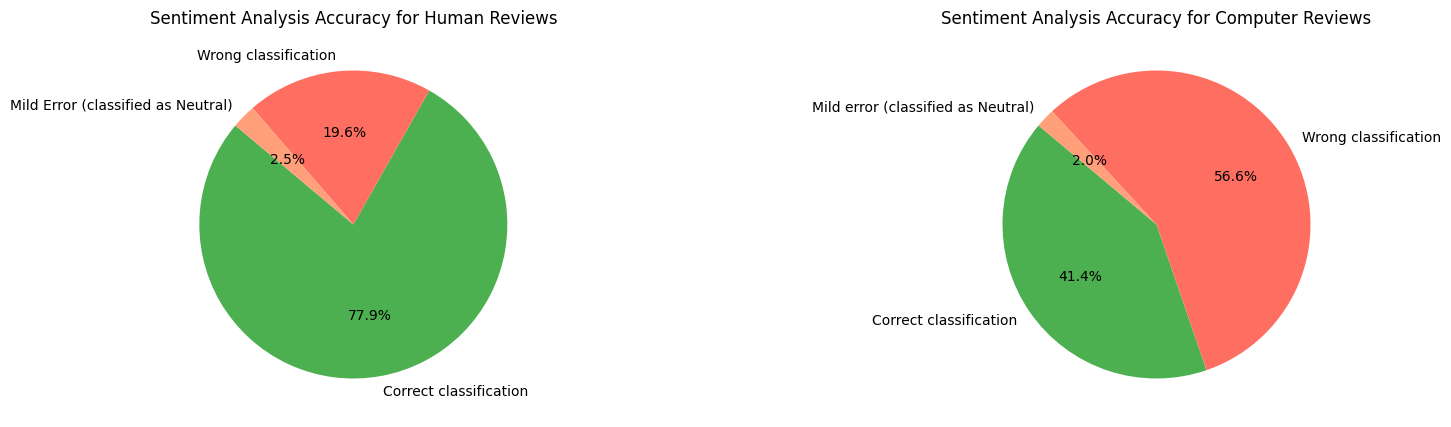

In [43]:
#CONFRONTO
import matplotlib.pyplot as plt
import numpy as np

#dati per il grafico a torta
human_classification = [human_correct_classification, human_wrong_classification]
computer_classification = [computer_correct_classification, computer_wrong_classification]
labels = ['Correct', 'Wrong']

#per recensioni scritte dagli umani
human_labels = ['Correct classification', 'Wrong classification', 'Mild Error (classified as Neutral)']
human_sizes = [human_correct_classification, human_wrong_classification, human_mild_error]
human_colors = ['#4CAF50', '#FF6F61', '#FFA07A']

plt.figure(figsize=(19,5))
plt.subplot(1,2,1)
plt.pie(human_sizes, labels=human_labels, autopct='%1.1f%%', colors=human_colors, startangle=140)
plt.title('Sentiment Analysis Accuracy for Human Reviews')

#per recensioni generate dal computer
computer_labels = ['Correct classification', 'Wrong classification', 'Mild error (classified as Neutral)']
computer_sizes = [computer_correct_classification, computer_wrong_classification, computer_mild_error]
computer_colors = ['#4CAF50', '#FF6F61', '#FFA07A']
plt.subplot(1,2,2)
plt.pie(computer_sizes, labels=computer_labels, autopct='%1.1f%%', colors=computer_colors, startangle=140)
plt.title('Sentiment Analysis Accuracy for Computer Reviews')

plt.show()

In [44]:
#grafici a torta per comparare l'efficacia della sentiment analysis su recensioni scritte da esseri umani rispetto
#a quelle generate dal computer. ogni grafico mostra la percentuale di recensioni classificate correttamente ed erroneamente
#obbiettivo: verificare quanto i computer riescano ad essere accurati nel generare recensioni con sentimento (??)

VEDERE SE STAMPARE ALCUNE RIGHE DI COMPUTER CLASSIFICATIONI SBAGLIATE PER VEDERE SE EFFETTIVAMENTE LE HA SCRITTE MALE. CON DEGLI ESEMPI

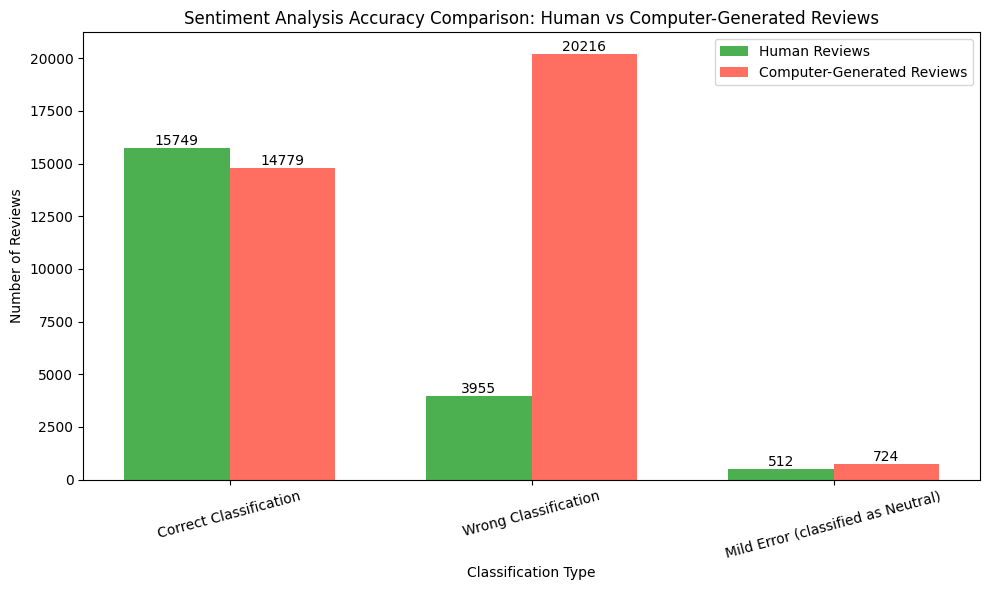

In [45]:
#GRAFICI A BARRE
labels=['Correct Classification', 'Wrong Classification', 'Mild Error (classified as Neutral)']
human_counts = [human_correct_classification, human_wrong_classification, human_mild_error]
computer_counts = [computer_correct_classification, computer_wrong_classification, computer_mild_error]

x = np.arange(len(labels))  #posizioni etichette
width = 0.35    #larghezza barre

#creazione grafico a barre
plt.figure(figsize=(10,6))
bar1 = plt.bar(x - width/2, human_counts, width, label='Human Reviews', color='#4CAF50')
bar2 = plt.bar(x + width/2, computer_counts, width, label='Computer-Generated Reviews', color='#FF6F61')

#etichette e titoli
plt.xlabel('Classification Type')
plt.ylabel('Number of Reviews')
plt.title('Sentiment Analysis Accuracy Comparison: Human vs Computer-Generated Reviews')
plt.xticks(x, labels, rotation=15)
plt.legend()

# Aggiungere i valori sopra le barre per le recensioni umane
for i, bar in enumerate(bar1):
    plt.text(bar.get_x() + bar.get_width() / 2, human_counts[i], int(human_counts[i]), ha='center', va='bottom')

# Aggiungere i valori sopra le barre per le recensioni generate dal computer
for i, bar in enumerate(bar2):
    plt.text(bar.get_x() + bar.get_width() / 2, computer_counts[i], int(computer_counts[i]), ha='center', va='bottom')


plt.tight_layout()
plt.show()

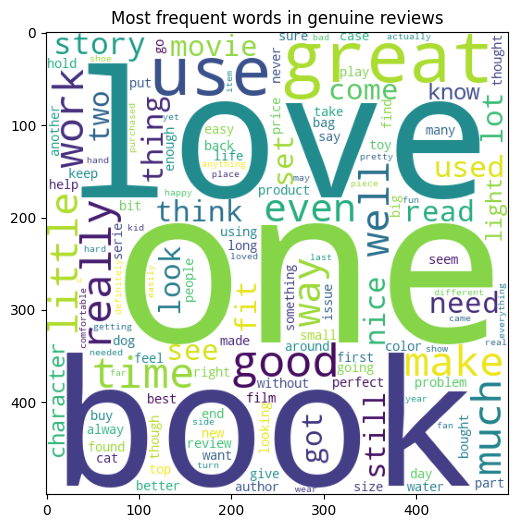

In [46]:
from wordcloud import WordCloud

#visuale delle parole più usate nelle recensioni vere
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')
fake_wc = wc.generate(df[df['label'] == 'OR']['processed_text'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.title("Most frequent words in genuine reviews")
plt.imshow(fake_wc)

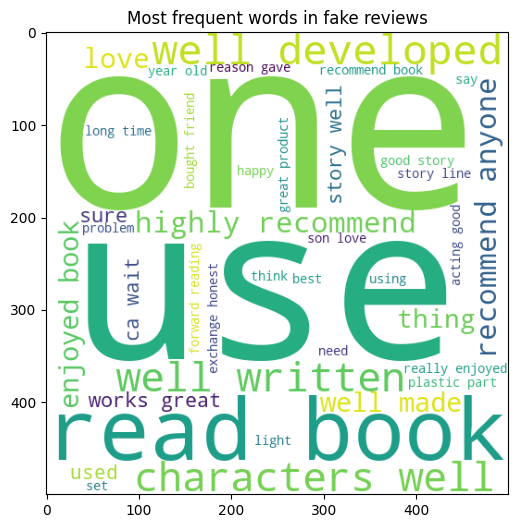

In [47]:
#visuale delle parole più usate nelle recensioni false
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')
fake_wc = wc.generate(df[df['label'] == 'CG']['processed_text'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.title("Most frequent words in fake reviews")
plt.imshow(fake_wc)

In [48]:
display(df)

,category,rating,label,text_,num_characters,num_words,num_sentences,cleaned_text,stemmed_text,processed_text,true_sentiment,sentiment,match
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor...",75,18,3,love well made sturdy comfortable love pretty,love well made sturdi comfort love pretti,love well made sturdy comfortable love pretty,Positive,Positive,1
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I...",80,19,2,love great upgrade original mine couple years,love great upgrad origin mine coupl year,love great upgrade original mine couple years,Positive,Positive,1
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...,67,16,2,pillow saved back love look feel pillow,pillow save back love look feel pillow,pillow saved back love look feel pillow,Positive,Positive,1
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i...",81,19,2,missing information use great product price,miss inform use great product price,missing information use great product price,Negative,Positive,0
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...,85,20,3,nice set good quality set two months,nice set good qualiti set two month,nice set good quality set two months,Positive,Positive,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
40427,Clothing_Shoes_and_Jewelry_5,4.0,OR,I had read some reviews saying that this bra r...,1698,379,22,read reviews saying bra ran small ordered two ...,read review say bra ran small order two band c...,read reviews saying bra ran small ordered two ...,Positive,Positive,1
40428,Clothing_Shoes_and_Jewelry_5,5.0,CG,I wasn't sure exactly what it would be. It is ...,1305,311,28,sure exactly would little large small size thi...,sure exactli would littl larg small size think...,sure exactly would little large small size thi...,Positive,Positive,1
40429,Clothing_Shoes_and_Jewelry_5,2.0,OR,"You can wear the hood by itself, wear it with ...",2007,414,26,wear hood wear hood wear jacket without hood s...,wear hood wear hood wear jacket without hood s...,wear hood wear hood wear jacket without hood s...,Negative,Positive,0
40430,Clothing_Shoes_and_Jewelry_5,1.0,CG,I liked nothing about this dress. The only rea...,1301,334,26,liked nothing dress reason gave stars ordered ...,like noth dress reason gave star order size fi...,liked nothing dress reason gave 4 stars ordere...,Negative,Positive,0


APPLICAZIONE ALGORITMI

In [49]:
#df.drop('true_sentiment', axis=1, inplace=True)
#df.drop('sentiment', axis=1, inplace=True)     #tolgo le info ridondanti, tengo solo se ha classificato bene. tanto se è positiva/negativa/neutra si vede dal rating



from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

X = df[['stemmed_text', 'rating', 'num_characters', 'sentiment']]
y=df['label']

#divido i dati in set di addestramento e test
X_train, X_test, y_train, y_test = train_test_split(X, df['label'], test_size=0.2, random_state=42)


### Algoritmo Randomico

#genero previsioni randomiche
np.random.seed(42)
y_pred_rnd = np.random.choice(['OR', 'CG'], size=len(df))

#valutazione dell'accuratezza del modello
accuracy_rnd = accuracy_score(df['label'], y_pred_rnd)
print(f'Accuratezza classificatore randomico: {accuracy_rnd:.2%}')

(ricordo che avendo il 50% in generale, conta quante erano genuine e quante false. ma in questo dataset sono esattemente lo stesso numero)
(legge dei grandi numeri)

### Logistic regression per l'assegnazione di una probabilità di appartenenza ad una classe


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, recall_score, precision_score

from sklearn.preprocessing import LabelEncoder

# Converti le etichette in valori numerici
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)  # Trasforma le etichette in numeri
y_test = encoder.transform(y_test)        # Trasforma anche le etichette di test

# TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train['stemmed_text'])
X_test_tfidf = tfidf_vectorizer.transform(X_test['stemmed_text'])

# Logistic Regression
model_lrp = LogisticRegression()
model_lrp.fit(X_train_tfidf, y_train)

# Previsioni
y_pred_lrp = model_lrp.predict(X_test_tfidf)

# Probabilità per ROC AUC
y_prob_lrp = model_lrp.predict_proba(X_test_tfidf)[:, 1]

# Metriche
accuracy_lpr = accuracy_score(y_test, y_pred_lrp)
precision_lrp = precision_score(y_test, y_pred_lrp)
recall_lrp = recall_score(y_test, y_pred_lrp)
f1_lrp = f1_score(y_test, y_pred_lrp)
auc_lrp = roc_auc_score(y_test, y_prob_lrp)

# Stampa dei risultati
print(f"Accuracy: {accuracy_lpr:.4f}")
print(f"Precision: {precision_lrp:.4f}")
print(f"Recall: {recall_lrp:.4f}")
print(f"F1-Score: {f1_lrp:.4f}")
print(f"ROC AUC Score: {auc_lrp:.4f}")


### Naive Bayes


from sklearn.naive_bayes import MultinomialNB

X = df['text_']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vettorizza il testo
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)


#inizializzo e addestro il modello
model_bayes = MultinomialNB()
model_bayes.fit(X_train, y_train)

#previsioni
y_pred_bayes = model_bayes.predict(X_test)

#valutazione
print(accuracy_score(y_test, y_pred_bayes))
print(classification_report(y_test,y_pred_bayes))


import joblib

#salvo il modello
joblib.dump(model_bayes, 'fake_review_detector.pkl')

In [50]:
#model_bayes = joblib.load('fake_review_detector.pkl')

LOGISTIC REGRESSION


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

#modello Logistic Regression
lr_model = LogisticRegression(max_iter=1000)

#alleno il modello
lr_model.fit(X_train, y_train)

#previsioni
y_pred_lr = lr_model.predict(X_test)

print("Accuracy Logistic Regression: {accuracy_score(y_test, y_pred_lr)}")
print(classification_report(y_test, y_pred_lr))


Confronto i risultati ottenuti da Naive Bayes e Logistic Regression

In [51]:
#matrice di confusione Logistic Regression
#print("Matrice di confusione Logistic Regression:\n")
#print(confusion_matrix(y_test, y_pred_lr))

Miglioramento prestazioni tramite ottimizzazione dei parametri

from sklearn.model_selection import GridSearchCV

#definisco i parametri da ottimizzzare
#testo 4 valori per c, che è il parametro per la regolarizzazione del modello (basso->algoritmo piu complesso perche si adatta meno al dataset)
#liblinear=solutore per semplici problemi binari; lbfgs=algoritmo piu complesso
param_grid_lr = {'C' : [0.1, 1, 10, 100], 'solver':['liblinear', 'lbfgs']}

#applico GridSearchCV (combino iperparametri di C per miglior modello)
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), param_grid_lr, cv=5)
grid_lr.fit(X_train, y_train)

print("Best parameters:\n")
print(grid_lr.best_params_)

#previsioni modello ottimizzato
y_pred_optimized_lr = grid_lr.predict(X_test)

#valudazione modello ottimizzato
print("Accuracy Logistic Regression Ottimizzata: {accuracy_score(y_test, y_pred_optimized)}")
print(classification_report(y_test, y_pred_optimized_lr))

In [52]:
#molto meglio!!

* Stampo altre informazioni utili che sono state trovate con l'applicazione di Logistic Regression

print("Best score: ")
print(grid_lr.best_score_)

#coefficienti del miglior modello
best_model_lr = grid_lr.best_estimator_
print("miglior combinazione di parametri:", best_model_lr)

print("Feature importance: ")
print(best_model_lr.coef_)

* Le feature (parole) piu importanti

In [53]:
#feature_names_lr = vectorizer.get_feature_names_out()
#coefficients_lr = best_model_lr.coef_[0]

#associa i coefficienti alle parole (feature) e le ordina per importanza
#important_feature_lr = sorted(zip(coefficients_lr, feature_names_lr), reverse=True)
#print("Top 10 most important features: ")
#for coef, word in important_feature_lr[:10]:
 #   print(f"{word} : {coef:.4f}")

* Stampo tutti i risultati della grid search

In [54]:
#print("All Grid Search Results: ")
#results = pd.DataFrame(grid_lr.cv_results_)
#print(results)

In [56]:
#decido di visualizzare solo risultati migliori
#filtered_results_lr = results[results['rank_test_score']>0.80]

#sorted_filtered_results_lr = filtered_results_lr.sort_values(by='mean_score_time', ascending=False)

#print("Combinazioni di parametri con punteggio medio >0.80: ")
#print(sorted_filtered_results_lr[['params', 'mean_score_time', 'std_test_score', 'rank_test_score']])

* GRAFICI ESPLICATIVI

#curva di Precision Recall
from sklearn.metrics import precision_recall_curve

y_scores_lr = lr_model.predict_proba(X_test)[:, 1]  # Probabilità per la classe positiva cioe 'OR'

#calcolo curva
precision, recall, thresholds = precision_recall_curve(y_test, y_scores_lr, pos_label='OR')


#grafico delle curve
plt.figure(figsize=(6,5))
plt.plot(recall, precision, marker='.', color='blue')
plt.title('Curva Precision-Recall')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.show()

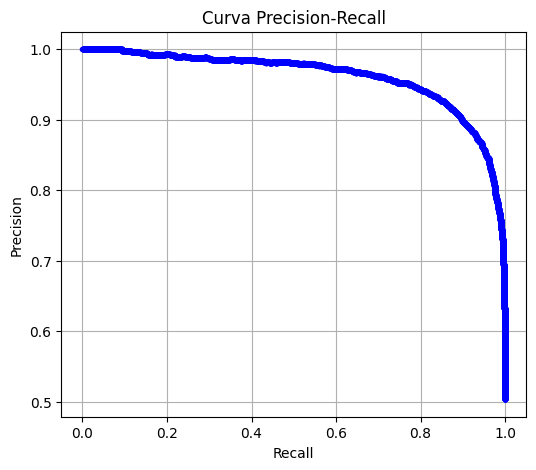

In [ ]:
#è molto buona perche la curva si avvicina abbastanza all'angolo in alto a dx -> alti livelli di richiamo

### RANDOM FOREST

Algoritmo di apprendimento supervisionato che sfrutta un insieme "foresta" di alberi decisionali. Ciascuno degli alberi è addestrato su un campione casuale DELLE FEATURE del training (così sono meno correlati e più diversi). Per la classificazione ogni albero emette un voto (previsione) e la classe finale è determinata dalla maggioranza dei voti. E' efficace su set grandi di dati complessi ed è meno sensibile all'overfitting dei singoli alberi decisionali. Valuta l'importanza delle caratteristiche e aiuta ad identificare quali variabili hanno maggiore impatto sulla decisione

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_recall_curve
import matplotlib.pyplot as plt

#creazione modello
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

#addestramento
model_rf.fit(X_train, y_train)

#previsioni
y_pred_rf = model_rf.predict(X_test)

#Valutazione
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy: {accuracy_rf:.2f}")
print("Classification Report: ")
print(classification_report(y_test, y_pred_rf))

#curva precision-recall
y_scores_rf = model_rf.predict_proba(X_test)[:, 1]     #prendi solo le probabilità con classe positiva 'OR'

precision, recall, thresholds = precision_recall_curve(y_test, y_scores_rf, pos_label='OR')


Accuracy: 0.88
Classification Report: 
              precision    recall  f1-score   support

          CG       0.86      0.92      0.89      4016
          OR       0.91      0.85      0.88      4071

    accuracy                           0.88      8087
   macro avg       0.89      0.88      0.88      8087
weighted avg       0.89      0.88      0.88      8087



#grafico della curva
plt.figure(figsize=(6,4))
plt.plot(recall, precision, marker='.', color='blue')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.show()

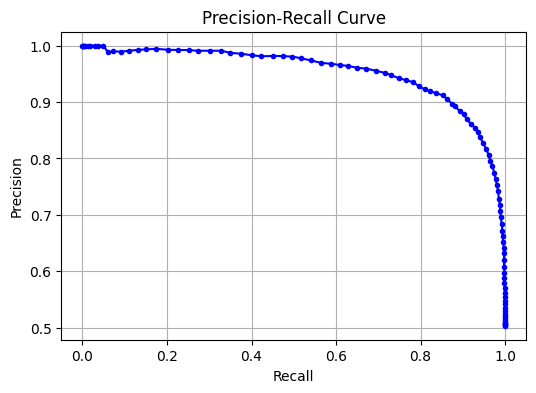

*Provo ad ottimizzare tramite una GridSearch*


#ottimizzo rispetto a: n_estimators, max_depth, min_sample_split, min_sample_leaf

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators' : [10, 20, 30],
    'max_depth' : [None, 10, 20, 30],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4]
}

grid_search = GridSearchCV(estimator=RandomForestClassifier(),
                           param_grid=param_grid,
                           cv=5,
                           n_jobs=-1)

grid_search.fit(X_train, y_train)
print("Best parameters found: ", grid_search.best_params_)

### DECISION TREE CLASSIFIER

Crea modello di classificazione rappresentato come un albero. Ogni nodo dell'albero rappresenta una condizionesu una caratteristica dei dati, mentre le foglie rappresentano la decisione finale. Si costruisce ricorsivamente. Per classificazioni semplici e interpretabili. Soffre di overfitting su dataset piccoli o molto variabili. (Domanda -> si/no e procede sulla domanda successiva fino alla foglia)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#creazione modello
#model_dt = DecisionTreeClassifier(random_state=42)

#addestramento
#model_dt.fit(X_train, y_train)

#previsioni
#y_pred_dt = model_dt.predict(X_test)

#valutazioni
#accuracy_dt = accuracy_score(y_test, y_pred_dt)
#print(f'Accuracy: {accuracy_dt:.2f}')

#print("Classification Report:")
#print(classification_report(y_test, y_pred_dt))

#print("Confusion Matrix:")
#print(confusion_matrix(y_test, y_pred_dt))

Accuracy: 0.78
Classification Report:
              precision    recall  f1-score   support

          CG       0.77      0.80      0.78      4016
          OR       0.79      0.76      0.78      4071

    accuracy                           0.78      8087
   macro avg       0.78      0.78      0.78      8087
weighted avg       0.78      0.78      0.78      8087

Confusion Matrix:
[[3199  817]
 [ 971 3100]]


from sklearn.tree import DecisionTreeClassifier, plot_tree

feature_names = vectorizer.get_feature_names_out()      #recupero i nomi delle features per capire che condizione il nodo stia usando


plt.figure(figsize=(20,20))
plot_tree(model_dt, feature_names=feature_names, class_names=model_dt.classes_, filled=True, rounded=True)
plt.title("Decision Tree")
plt.show()


In [ ]:
from scipy.stats import pearsonr

# Converte il sentiment in valori numerici
#sentiment_mapping = {"positive": 1, "neutral": 0, "negative": -1}
#df["sentiment_numeric"] = df["sentiment"].map(sentiment_mapping)

# Calcola la correlazione di Pearson
#rating_corr, _ = pearsonr(df["sentiment_numeric"], df["rating"])
#char_count_corr, _ = pearsonr(df["sentiment_numeric"], df["num_characters"])

# Mostra i risultati
#print(f"Correlazione tra Sentiment e Rating: {rating_corr:.2f}")
#print(f"Correlazione tra Sentiment e Numero di Caratteri: {char_count_corr:.2f}")


Correlazione tra Sentiment e Rating: nan
Correlazione tra Sentiment e Numero di Caratteri: nan


### K-NEIGHBORS CLASSIFIER

Si basa sulla vicinanza: per classificare un nuovo punto, considera i K punti piu vicini nel dataset di addestramento e gli assegna la classe piu comune tra di essi. In genere usa la distanza Euclidea ma puo usarne anche altri tipi. Ordina i K punti in base alla vicinanza.

In [59]:
from sklearn.neighbors import KNeighborsClassifier

#creazione modello
k=5
model_knn = KNeighborsClassifier(n_neighbors=k)

#addestramento
model_knn.fit(X_train, y_train)

#previsioni
y_pred_knn = model_knn.predict(X_test)

#valutazione
print("Accuracy:", accuracy_score(y_test, y_pred_knn))

print("Classification Report:\n", classification_report(y_test, y_pred_knn))

Accuracy: 0.5851366390503276
Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.92      0.69      4016
           1       0.77      0.25      0.38      4071

    accuracy                           0.59      8087
   macro avg       0.66      0.59      0.53      8087
weighted avg       0.66      0.59      0.53      8087



In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# Supponiamo che X siano i dati di input e y siano le etichette
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Usa StandardScaler con with_mean=False
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Inizializzazione e addestramento del modello KNeighbors
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train_scaled, y_train)

# Previsione e valutazione
y_pred = model_knn.predict(X_test_scaled)


ValueError: Cannot center sparse matrices: pass `with_mean=False` instead. See docstring for motivation and alternatives.

### ADA BOOST


Combina diversi modelli di apprendimento debole (alberi decisionali) per crearne uno più forte. Assegna pesi i campioni di addestramento e li aggiorna in base a quanto bene ciascun modello riesce a classificare i dati. All'inizio hanno tutti lo stesso peso. Viene addestrato il modello e aggiornati i pesi (aumentati o diminuiti in base alla corretta classificazione). Vengono ripetuti questi passaggi per 2-4 volte o fino al raggiungimento di un certo livello di prestazione

In [65]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

base_classifier = DecisionTreeClassifier(max_depth=1)

model_adaboost = AdaBoostClassifier(base_classifier, n_estimators=50, random_state=42)

model_adaboost.fit(X_train, y_train)

y_pred_adab = model_adaboost.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_adab))
print("Classification Report:\n", classification_report(y_test, y_pred_adab))

c:\Users\ludov\Documents\fake-reviews-project\env\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Accuracy: 0.7435390132311117
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.69      0.73      4016
           1       0.72      0.80      0.76      4071

    accuracy                           0.74      8087
   macro avg       0.75      0.74      0.74      8087
weighted avg       0.75      0.74      0.74      8087



#miglioro il modello
param_grid = {
    'n_estimators': [10, 50, 100],
    'learning_rate': [0.01, 0.1, 1]
}

grid_search = GridSearchCV(AdaBoostClassifier(base_classifier), param_grid, cv=5)
grid_search.fit(X_train, y_train)

print("Migliori parametri:", grid_search.best_params_)

### EXTREME GRADIENT BOOST

Usa numerosi modelli (in genere alberi decisionali) in modo sequenziale dove ogni modello corregge gli errori di quelli precedenti, migliorando la capacità predittiva. Molto buono su dati sbilanciati per accuratezza ed efficienza.

In [ ]:
from xgboost import XGBClassifier

#trasformo le etichette 'OR' e 'CG' in etichette numeriche 1 e 0
from sklearn.preprocessing import LabelEncoder

def encode_label(df):
    labels = {
        'CG': 0,
        'OR': 1
    }
    df['label'] = df['label'].str.strip()

    df['label'] = df['label'].map(labels)
    
    return df

df = encode_label(df)

display(df)


,category,rating,label,text_,num_characters,num_words,num_sentences,cleaned_text,stemmed_text,processed_text,true_sentiment,sentiment,match,sentiment_numeric
0,Home_and_Kitchen_5,5.0,0,"Love this! Well made, sturdy, and very comfor...",75,18,3,love well made sturdy comfortable love pretty,love well made sturdi comfort love pretti,love well made sturdy comfortable love pretty,Positive,Positive,1,NaN
1,Home_and_Kitchen_5,5.0,0,"love it, a great upgrade from the original. I...",80,19,2,love great upgrade original mine couple years,love great upgrad origin mine coupl year,love great upgrade original mine couple years,Positive,Positive,1,NaN
2,Home_and_Kitchen_5,5.0,0,This pillow saved my back. I love the look and...,67,16,2,pillow saved back love look feel pillow,pillow save back love look feel pillow,pillow saved back love look feel pillow,Positive,Positive,1,NaN
3,Home_and_Kitchen_5,1.0,0,"Missing information on how to use it, but it i...",81,19,2,missing information use great product price,miss inform use great product price,missing information use great product price,Negative,Positive,0,NaN
4,Home_and_Kitchen_5,5.0,0,Very nice set. Good quality. We have had the s...,85,20,3,nice set good quality set two months,nice set good qualiti set two month,nice set good quality set two months,Positive,Positive,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40427,Clothing_Shoes_and_Jewelry_5,4.0,1,I had read some reviews saying that this bra r...,1698,379,22,read reviews saying bra ran small ordered two ...,read review say bra ran small order two band c...,read reviews saying bra ran small ordered two ...,Positive,Positive,1,NaN
40428,Clothing_Shoes_and_Jewelry_5,5.0,0,I wasn't sure exactly what it would be. It is ...,1305,311,28,sure exactly would little large small size thi...,sure exactli would littl larg small size think...,sure exactly would little large small size thi...,Positive,Positive,1,NaN
40429,Clothing_Shoes_and_Jewelry_5,2.0,1,"You can wear the hood by itself, wear it with ...",2007,414,26,wear hood wear hood wear jacket without hood s...,wear hood wear hood wear jacket without hood s...,wear hood wear hood wear jacket without hood s...,Negative,Positive,0,NaN
40430,Clothing_Shoes_and_Jewelry_5,1.0,0,I liked nothing about this dress. The only rea...,1301,334,26,liked nothing dress reason gave stars ordered ...,like noth dress reason gave star order size fi...,liked nothing dress reason gave 4 stars ordere...,Negative,Positive,0,NaN


In [ ]:
print(df['label'].apply(type).value_counts())


label
<class 'int'>    40432
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
X['text_'] = le.fit_transform(X['text_'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#creazione modello
model_xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)


#addestramento
model_xgb.fit(X_train, y_train)

#previsioni
y_pred_xgb = model_xgb.predict(X_test)

#valutazione
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))

KeyError: 'text_'

In [ ]:
import gc

# Esempio: eliminare un modello o un oggetto che non ti serve più
del model_rf  # o qualsiasi altro oggetto che vuoi rimuovere

gc.collect()  # Forza la garbage collection

# DEEP LEARNING

import numpy as np
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers
from scipy.sparse import csr_matrix


y_train = np.array(['OR', 'CG'])

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)  # Codifica le etichette
y_train_encoded = y_train_encoded.astype(np.int32)  # Converti in tipo intero

X_train = csr_matrix(np.random.rand(len(y_train), 36975))  # Sostituisci con il tuo array di feature sparso

scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train)
X_train_dense = X_train_scaled.toarray()

X_test_scaled = scaler.transform(X_test)




### Creazione rete neurale


model = keras.Sequential([
    layers.Dense(128, input_shape=(X_train_scaled.shape[1],), activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')       ## per uscita binaria
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# allenamento della rete neurale sul set di training
history = model.fit(X_train_dense, y_train, epochs=50, batch_size=32, validation_split=0.2)


# Funzione generatore
def data_generator(X, y, batch_size):
    while True:
        for start in range(0, len(y), batch_size):
            end = min(start + batch_size, len(y))
            yield X[start:end].toarray(), y[start:end]  # Converti solo il batch in denso

# Addestramento del modello
batch_size = 32
steps_per_epoch = len(y_train_encoded) // batch_size

model.fit(data_generator(X_train_scaled, y_train_encoded, batch_size),
          steps_per_epoch=len(y_train_encoded) // batch_size,
          epochs=10)

test_loss, test_acc = model.evaluate(X_test_scaled, y_test)
print(f"Test Accuracy: {test_acc: .2f}")